In [5]:
import gc
# import torch

gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

import os
os.listdir(); os.chdir("/aiau010_scratch/azm0269/clover/")
os.environ['HF_HOME'] = "/aiau010_scratch/azm0269/hub"
os.environ['TORCH_HOME'] = "/aiau010_scratch/azm0269/clover/.cache/torch"

from clover.utils.utils import notebook_line_magic
notebook_line_magic()

In [2]:
import pandas as pd

path = "/aiau010_scratch/azm0269/clover/outputs/md3po_sac/seed_123/training_evals/images/eval_manifest.json"
prompts = pd.read_json(path)

In [3]:
selection_prompts = ['a dog riding a bike', 'a cat playing chess', 'a monkey washing dishes']
selection = prompts[prompts["prompt"].str.contains('|'.join(selection_prompts))]
selection = selection[selection['epoch'].isin([5, 9])]
selection.drop_duplicates(subset=['prompt', 'epoch'], keep='last', inplace=True)

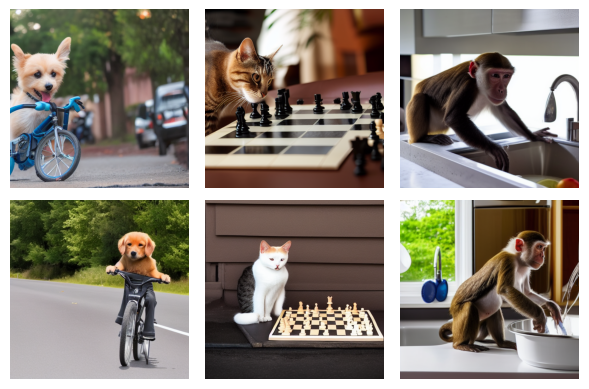

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

plot_epochs = sorted(selection["epoch"].unique())
prompt_order = selection_prompts
figure, axes = plt.subplots(
    len(plot_epochs),
    len(prompt_order),
    figsize=(2 * len(prompt_order), 2 * len(plot_epochs)),
    squeeze=False,
)

for row, epoch in enumerate(plot_epochs):
    epoch_selection = selection[selection["epoch"] == epoch].set_index("prompt")
    missing = set(prompt_order).difference(epoch_selection.index)
    if missing:
        raise ValueError(f"Epoch {epoch} is missing prompts: {sorted(missing)}")
    for column, prompt in enumerate(prompt_order):
        with Image.open(epoch_selection.at[prompt, "image"]) as image:
            axes[row, column].imshow(image.convert("RGB"))
        axes[row, column].set_axis_off()
        # if row == 0:
            # axes[row, column].set_title(prompt)
        # if column == 0:"
        #     axes[row, column].text(
        #         -0.08,
        #         0.5,
        #         f"$ \tau $ {epoch-}",
        #         rotation=90,
        #         va="center",
        #         ha="right",
        #         transform=axes[row, column].transAxes,
        #         fontsize=12,
        #     )

# figure.suptitle("Selected prompt images across epochs", fontsize=14)
figure.tight_layout()


### Cross-epoch Inception Score for the selected prompts

Rows contain the three selected prompts at epoch 5 and columns contain the same prompts at epoch 9. Each cell starts from the Inception Score of its row and column image pair, using one split. All scores are then divided by the sum of the three diagonal scores, so the normalized diagonal sums to 1. The diagonal therefore shows the relative variation of the same prompt across epochs within its row.


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from clover.utils.diversity_score import inception_score

epochs = sorted(selection["epoch"].unique())
if len(epochs) != 2:
    raise ValueError(f"Expected exactly two selected epochs, found {epochs}")
row_epoch, column_epoch = epochs
prompt_order = selection_prompts

def images_by_prompt(epoch):
    epoch_selection = selection[selection["epoch"] == epoch].set_index("prompt")
    missing = set(prompt_order).difference(epoch_selection.index)
    if missing:
        raise ValueError(f"Epoch {epoch} is missing prompts: {sorted(missing)}")
    images = {}
    for prompt in prompt_order:
        with Image.open(epoch_selection.at[prompt, "image"]) as image:
            images[prompt] = image.convert("RGB").copy()
    return images

row_images = images_by_prompt(row_epoch)
column_images = images_by_prompt(column_epoch)
score_values = np.empty((len(prompt_order), len(prompt_order)), dtype=float)
for row, row_prompt in enumerate(prompt_order):
    for column, column_prompt in enumerate(prompt_order):
        score, _ = inception_score(
            [row_images[row_prompt], column_images[column_prompt]],
            splits=1,
        )
        score_values[row, column] = score

diagonal_sum = np.trace(score_values)
normalized_score_values = np.divide(
    score_values,
    diagonal_sum,
    out=np.zeros_like(score_values),
    where=diagonal_sum != 0,
)

inception_score_matrix = pd.DataFrame(
    normalized_score_values,
    index=pd.Index(prompt_order, name=f"Epoch {row_epoch} prompt"),
    columns=pd.Index(prompt_order, name=f"Epoch {column_epoch} prompt"),
)
# eval_directory = Path("outputs/md3po_sac/evals")
# eval_directory.mkdir(parents=True, exist_ok=True)
# inception_score_matrix.to_csv(eval_directory / "selected_prompt_inception_score_matrix.csv")
inception_score_matrix.round(2)


Epoch 9 prompt,a dog riding a bike,a cat playing chess,a monkey washing dishes
Epoch 5 prompt,,,
a dog riding a bike,0.32,0.44,0.39
a cat playing chess,0.42,0.41,0.43
a monkey washing dishes,0.42,0.46,0.27


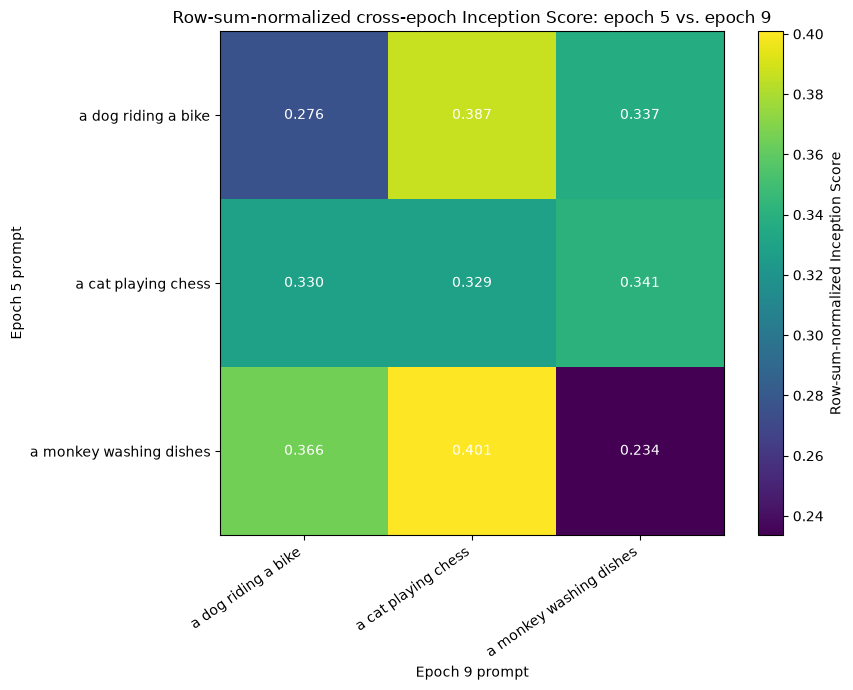

In [11]:
figure, axis = plt.subplots(figsize=(9, 7))
heatmap = axis.imshow(inception_score_matrix.to_numpy(), cmap="viridis")
figure.colorbar(heatmap, ax=axis, label="Diagonal-normalized Inception Score")
axis.set_xticks(range(len(prompt_order)), labels=prompt_order, rotation=35, ha="right")
axis.set_yticks(range(len(prompt_order)), labels=prompt_order)
for row in range(len(prompt_order)):
    for column in range(len(prompt_order)):
        axis.text(column, row, f"{normalized_score_values[row, column]:.3f}", ha="center", va="center", color="white")
axis.set_title(f"Diagonal-normalized cross-epoch Inception Score: epoch {row_epoch} vs. epoch {column_epoch}")
axis.set_xlabel(f"Epoch {column_epoch} prompt")
axis.set_ylabel(f"Epoch {row_epoch} prompt")
figure.tight_layout()
